<a name="Notebook-Start"></a>

---

<font size = 7> <b> Lesson 2.1 (Simple Linear Models) </b> </font>

---

<font size = 5> <b> Notebook Index </b> </font>

1.  [Learning Outcomes](#Learning-Outcomes)

2.  [Introduction](#Introduction)

3.  [Import Python Libraries](#Import-Python-Libraries)

4.  [Define Useful Functions](#Define-Useful-Functions)

5.  [Load The Dataset](#Load-The-Dataset)

6.  [Investigation: Explore The Data](#Investigation)

7.  [Abstraction: Develop A Model](#Abstraction)

8.  [Implementation: Trying Specific Models](#Implementation)

9.  [Validation: Introducing Error and Loss Functions](#Validation)

10. [Iteration: Improving the Model](#Iteration)

11. [Interpretation: Gaining Physical Understanding](#Interpretation)

12. [Lesson Summary](#Lesson-Summary)

13. [Appendix A: New Term Definitions](#Appendix-Definitions)
$
\newcommand{\lsum}{\displaystyle \sum\limits_{i=1}^{N}}
\newcommand{\parens}[1]{\left(#1\right)}
\newcommand{\dsfrac}[2]{\displaystyle\frac{#1}{#2}}
\newcommand{\dpfrac}[2]{\displaystyle\parens{\frac{#1}{#2}}}
\newcommand{\parderiv}[2]{\dsfrac{\partial #1}{\partial #2}}
\newcommand{\spc}{\hspace{0.1 pc}}
\newcommand{\ra}{\Rightarrow}
\newcommand{\of}[1]{{\scriptsize (#1)}}
\newcommand{\rule}{\Huge \hspace{-0.2 pc} \displaystyle\frac{\hspace{20 pc}}{\hspace{20 pc}}}
\newcommand{\mps}{\spc \frac{\textrm{m}}{\textrm{s}}}
\newcommand{\mpss}{\spc \frac{\textrm{m}}{\textrm{s}^2}}
$

<a name="Learning-Outcomes"></a>

---

<font size = 6> <b> 1. Learning Outcomes </b> </font>

---

<font size = 5> <b> Learning Outcomes: </b> </font>

By the end of this lesson, students will be able to:

  <br>

  1. <b>Explain</b> the purpose and limitations of [models](#Definition-Model) in science and engineering, including how they are used to understand [systems](#Definition-System), make [predictions](#Definition-Prediction), and optimize performance, as well as recognizing the needed balance between simplicity and accuracy.

  2. <b>Identify</b> a real-world system, select appropriate [features](#Definition-Feature) and [target](#Definition-Target) variables, and describe the assumptions involved in modeling.

  3. <b>Construct and Interpret</b> a simple [linear model](#Definition-Linear-Model) based on empirical data, including defining the mathematical relationship between features and target.

  4. <b>Visualize and Analyze</b> data using [scatterplots](#Definition-Scatterplot) to identify trends and guide model development.

  5. <b>Evaluate</b> model performance by calculating a model's [error](#Definition-Error) and using a [loss function](#Definition-Loss-Function) such as [Root Mean Squared Error](#Definition-RMSE) (RMSE) to interpret the model's accuracy.

  6. <b>Reflect</b> on modeling as an iterative process, using techniques such as a [parameter search](#Definition-Parameter-Search) to improve a model's accuracy.

[Return to Top](#Notebook-Start)

<a name="Introduction"></a>

---

<font size = 6> <b> 2. Introduction </b> </font>

---

<font size = 5> <b> 2.1 Why Do We Create Models? </b> </font>

<p align = 'justify'>
Real-world [systems](#Definition-System) are often messy and/or complicated and analyzing them directly might be impractical, or even impossible. Creating a [model](#Definition-Model) helps us zoom in on the most important aspects of a system, ignore what's less relevant, and build a simplified version of the system that's easier to work with, but still meaningful. We build models for three main reasons:
</p>

<br>

1. <b>To Understand How a System Behaves</b>:

    <p align = 'justify'>
    Even if we don’t fully understand why a system behaves the way it does, a model that accurately mimics a system's behavior can help us identify which parts of the system have the biggest influence on that behavior.
    </p>

    ><b>Example</b>: "Does an engine's horsepower or its mass matter more to its fuel efficiency?"

<br>

2. <b>To Make Predictions</b>:
  
    <p align = 'justify'>
    If a model reliably reflects a system's past behavior, we can use it to anticipate what might happen to the system in the near future.
    </p>

    ><b>Example</b>: “Based on today's weather, will it rain tomorrow?”

  <br>

3. <b>To Optimize Performance</b>:

    <p align = 'justify'>
    Once we have a working model, we can tweak the inputs and observe the outcomes to improve system performance.
    </p>

    ><b>Example</b>: “If we tilt the windmill blade by one more degree, will it generate more power?”

<br>

<p align = 'justify'>
These goals (<b>understanding</b>, <b>predicting</b>, and <b>improving</b>) are at the heart of why we build models in science, engineering, economics, and beyond.
</p>

<center>$\rule$</center>

<font size = 5> <b> 2.2 What Are The Limits Of Modeling? </b> </font>

In 1976, British statistician George Box famously wrote:

><b>"All models are wrong, but some are useful."</b>

<br>

<p align = 'justify'>
What did he mean? Simply put, every [model](#Definition-Model) is a simplification. No model perfectly captures the complexity of the real world. <b>But, that's okay!</b> A model doesn't have to be perfect to be useful. Even imperfect models can help us understand, predict, and improve the [systems](#Definition-System) around us.
</p>

<br>

><p align = 'justify'>
<b>Note</b>: A useful model does more than just spit numbers at us. It helps us connect data with meaning, and gives structure to systems that might otherwise feel too complex to understand.
</p>

<center>$\rule$</center>

<font size = 5> <b> 2.3 How Do We Build A Model? </b> </font>

<p align = 'justify'>
<a href = #Definition-Model><b>Model</b></a> building is a step-by-step process, similar to the scientific method. We use it in science, engineering, medicine, and many other data-driven fields. Later in this lesson, we use a concrete example to guide us through each of the steps in this process. For now, we start with a look at a general overview of these steps:
</p>

<br>

  * <b>Step 1: Investigation</b>

    Start by gathering data and observations about the [system](#Definition-System).

    ><b>Example</b>: You observe that dropped objects fall faster the longer they're in the air. You then begin collecting real-world data by recording a series of measurements of objects' speed and fall time.

  <br>

  * <b>Step 2: Abstraction</b>

    - Define what you're trying to understand or predict about the system (the [target](#Definition-Target)).
    - Choose which aspects of the system to include (the [features](#Definition-Feature)).
    - Outline how those features might influence the target.

    ><b>Example</b>: You decide that you want to be able to predict the speed of an object (your target) given the amount of time that the object has been falling (your feature). You choose a simple [linear model](#Definition-Linear-Model) to describe the relationship.

  <br>

  * <b>Step 3: Implementation</b>

    Choose specific values for the features and use the model to make predictions of the target.

    ><b>Example</b>: You assign a [linear coefficient](#Definition-Linear-Coefficient) and [bias](#Definition-Bias) to your model and use it to predict the speed of a freefalling object at a given time.

  <br>

  * <b>Step 4: Validation</b>

    Compare the model’s predictions with actual real-world data to see how well it performs.

    ><b>Example</b>: You compare your model's predicted speed at a given time to the actual data for the speed of an object falling for that amount of time.

  <br>

  * <b>Step 5: Iteration</b>
  
    Refine the model based on its performance.

    ><b>Example</b>: You see that your prediction is off, so you adjust the model's parameters (linear coefficient and bias) and re-test your new predictions against the real-world data.

  <br>

  * <b>Step 6: Interpretation</b>

    Use the model to gain insight into how the system works.

    ><b>Example</b>: Once your model fits the data well, you interpret the linear coefficient as representing the object's acceleration due to local gravity and the bias as the object's initial velocity.

<br>

This cycle, especially the iteration step, is key. Modeling isn't about finding a perfect answer. It's about improving our understanding of the systems that shape the world around us.

<center>$\rule$</center>

<font size = 5> <b> 2.4 Simplicity Vs Accuracy: Which Is Better? </b> </font>

All three modeling goals(understanding, prediction, and optimization) depend on finding the right balance between simplicity and accuracy.

<br>

  * If a [model](#Definition-Model) is too simple, it might miss important aspects of the [system](#Definition-System) and lead us to incorrect conclusions.

  <br>

  * If a model is too complex, it could be hard to understand, slow to run, or too cumbersome to be useful.

<br>

In the end, the goal isn't to build the most detailed or "realistic" model possible. The goal is to build one that's useful for the task at hand. That's why the validation and iteration steps are so important. <b>A model is "finished" not when it's perfect, but when it's good enough to serve its intended purpose.</b>

[Return to Top](#Notebook-Start)

<a name="Import-Python-Libraries"></a>

---

<font size = 6> <b> 3. Import Python Libraries </b> </font>

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display_html

[Return to Top](#Notebook-Start)

<a name="Define-Useful-Functions"></a>

---

<font size = 6> <b> 4. Define Useful Functions </b> </font>

---

In [2]:
#@title This cell defines the display_dataframes and plot_data functions.

##=============================================================================================##
## Function:  display_dataframes                                                               ##
##                                                                                             ##
## Purpose:   Display multiple DataFrames side-by-side with titles                             ##
##                                                                                             ##
## Input(s):  item_list  - List of DataFrames to be displayed                                  ##
##            title_list - List of titles for the displayed DataFrames                         ##
##                                                                                             ##
## Output(s): None                                                                             ##
##=============================================================================================##

def display_dataframes(item_list, title_list):

  # Create a String for housing the commands to be sent to the display_html() function:

  html_str = ''

  # Loop over the elements in the item_list and title_list:

  for df, title in zip(item_list, title_list):

      # Wrap title and dataframe in a styled html <div>:

      html_str += f'''
      <div style="display: inline-block; margin-right: 20px; vertical-align: top;">
          <h3 style="text-align: center;">{title}</h3>
          {pd.DataFrame(df).head().to_html()}
      </div>
      '''

  # Send the html String to the display_html() function for interpretation:

  display_html(html_str, raw = True)

##=============================================================================================##
## Function:  plot_data                                                                        ##
##                                                                                             ##
## Purpose:   Create a scatterplot with optional model overlays and error bands                ##
##                                                                                             ##
## Input(s):  data          - List of data points [x_data, y_data]                             ##
##            title         - Graph title                                                      ##
##            axis_labels   - Override axis labels [x_label, y_label] (optional)               ##
##            model_list    - List of model predictions to overlay (optional)                  ##
##            color_list    - Colors for each model line (optional)                            ##
##            label_list    - Labels for each model line (optional)                            ##
##            error_display - Show +/- error band around first model (default is False)        ##
##            error         - Error value for shaded band                                      ##
##                                                                                             ##
## Output(s): graph       - Matplotlib axes object, can be used for overplotting               ##
##=============================================================================================##

def plot_data(data, title, axis_labels = [], model_list = [], color_list = [], label_list = [],
              error_display = False, error = 0):

  # Create the Matplotlib figure:

  figure = plt.figure(figsize = (12, 9))

  # Add a graph to the figure:

  graph = figure.add_subplot()

  # Set the graph background Color:

  graph.set_facecolor('lightcyan')

  # Create a scatterplot of the data:

  sns.scatterplot(x = data[0], y = data[1], ax = graph)

  # Overlay model predictions:

  for i in range(0, len(model_list)):

    graph.plot(data[0], model_list[i], color = color_list[i], label = label_list[i])

  # Set the graph title:

  graph.set_title(title, fontsize = 20)

  # Set the x_label and y_label:

  if (axis_labels != []):

    graph.set_xlabel(axis_labels[0], fontsize = 14)

    graph.set_ylabel(axis_labels[1], fontsize = 14)

  # Apply a grid to the graph:

  graph.grid(which = 'both')

  # Adjust the x-axis scale of the graph:

  graph.autoscale(enable = True, axis = 'x', tight = False)

  # Adjust the y-axis scale of the graph:

  graph.autoscale(enable = True, axis = 'y', tight = False)

  # If requested, show the +/- error bounds:

  if ((error_display == True) and model_list != []):

    model_plus_error  = model_list[0] + error
    model_minus_error = model_list[0] - error

    error_df = pd.DataFrame({
        'X-Data': data[0],
        'Model+Error': model_plus_error,
        'Model-Error': model_minus_error
    }).sort_values(by="X-Data")

    graph.fill_between(error_df['X-Data'], error_df['Model+Error'], error_df['Model-Error'],
                       alpha = 0.5, color = (0.6, 0.6, 0.6), label = "Error Bounds")

  # Add the graph legend

  if (label_list != []): graph.legend()

  # Return the graph object

  return graph

[Return to Top](#Notebook-Start)

<a name="Load-The-Dataset"></a>

---

<font size = 6> <b> 5. Load The Dataset </b> </font>

---

<font size = 5> <b> 5.1 What Kind Of Data Are We Using? </b> </font>

In this lesson, we work with a [synthetic dataset](#Definition-Synthetic-Dataset) that [simulates](#Definition-Simulation) measurements of an object in free fall near Earth's surface.

![Dropped Ball](https://raw.githubusercontent.com/dr-bankert-augustana/PHYS_200/refs/heads/main/Images/Module_2/object_drop.gif)

When creating this data, two key simplifications were made.

  <br>

  1. The object is falling without <b>without air resistance</b>.

  <br>

  2. The object starts with <b>zero initial speed</b>.

  <br>

These simplifications were made to allow us to focus on introducing the modeling process without needing to deal with extra complications.

<center>$\rule$</center>

<font size = 5> <b> 5.2 What's In The Dataset? </b> </font>

Each row in the [dataset](#Definition-Dataset) represents a single measurement taken during the object's fall and includes:

  <br>

  * <b>Time (s)</b>: How many seconds have passed since the object started falling

  <br>

  * <b>Speed (m/s)</b>: The object's speed at the moment of measurement, in meters per second

<center>$\rule$</center>

<font size = 5> <b> 5.3 Why This Dataset? </b> </font>

This simple [system](#Definition-System) (an object falling in a vacuum) is perfect for learning how to build and test basic [models](#Definition-Model). Even though the [dataset](#Definition-Dataset) is [synthetic](#Definition-Synthetic-Dataset), it mirrors real physical behavior in a way that's easy to understand and mathematically clean. Using this dataset, we can explore how data helps us:

  <br>

  * <b>Understand physical behavior</b>:
  
    ><b>Example</b>: How does an object's speed change over time?

  <br>

  * <b>Predict future outcomes</b>:
  
    ><b>Example</b>: What will the object's speed be after 5 seconds of falling?

  <br>

  * <b>Optimize or estimate unknowns</b>:
  
    ><b>Example</b>: Can we use the data to figure out the acceleration due to local gravity?

<br>

Using clean, idealized data lets us focus on the modeling process itself, and build a solid foundation before tackling more complex systems later on.

In [4]:
##=============================================================================================##
## Load The Full Data Set:                                                                     ##
##=============================================================================================##

github = "https://raw.githubusercontent.com/dr-bankert-augustana/PHYS_200/refs/heads/main/"

url = github + "Data/Module_2/freefall_data_1.csv"

full_data = pd.read_csv(url)

##=============================================================================================##
## Clean the Data and Separate Features and Targets:                                           ##
##=============================================================================================##

# Remove any rows missing data:

cleaned_data = full_data.dropna()

# Identify the feature data:

X = cleaned_data["Time (s)"]

# Identify the target data:

y = cleaned_data["Speed (m/s)"]

##=============================================================================================##
## Display the Full Dataset, Feature Data, and Target Data:                                    ##
##=============================================================================================##

# Display the feature and target data:

display_dataframes([full_data, X, y], ["Full Dataset", "Feature Data", "Target Data"])

Full Dataset 
 
 
 
 
 Time (s) 
 Speed (m/s) 
 Position (m) 
 
 
 
 
 0 
 0.0202 
 0.2118 
 -0.0112 
 
 
 1 
 0.0221 
 0.2159 
 -0.0032 
 
 
 2 
 0.0278 
 0.2953 
 -0.0187 
 
 
 3 
 0.0368 
 0.2862 
 -0.0814 
 
 
 4 
 0.0618 
 0.6551 
 -0.0298 
 
 
 
 
 
 
 Feature Data 
 
 
 
 
 Time (s) 
 
 
 
 
 0 
 0.0202 
 
 
 1 
 0.0221 
 
 
 2 
 0.0278 
 
 
 3 
 0.0368 
 
 
 4 
 0.0618 
 
 
 
 
 
 
 Target Data 
 
 
 
 
 Speed (m/s) 
 
 
 
 
 0 
 0.2118 
 
 
 1 
 0.2159 
 
 
 2 
 0.2953 
 
 
 3 
 0.2862 
 
 
 4 
 0.6551

[Return to Top](#Notebook-Start)

<a name="Investigation"></a>

---

<font size = 6> <b> 6. Investigation: Explore The Data </b> </font>

---

<font size = 5> <b> 6.1 Exploring A System Through Data </b> </font>

Before we can build a [model](#Definition-Model), we need to <b>investigate</b> the [system](#Definition-System) and develop a good understanding of how it behaves. One of the most effective ways to do that is through experimentation; observing the system and collecting data on how it responds under different conditions. In some cases, that means conducting experiments ourselves. But that's not always practical. We might not have access to the right tools, enough time, or the budget to conduct our own experiments. In those situations, we need to seek out reliable data that might already exist.

<br>

><b>Example</b>: We're probably not going to launch our own satellite to study stars, but we can still build models using astronomical data gathered by space agencies and observatories.

<br>

In our case, we're working with a [synthetic dataset](#Definition-Synthetic-Dataset) that [simulates](#Definition-Simulation) measurements of a falling object. This gives us a controlled, simplified system that we can analyze without worrying about time or equipment limitations.

<center>$\rule$</center>

<font size = 5> <b> 6.2 Visualizing Our Data</b> </font>

A useful early step in analyzing our [dataset](#Definition-Dataset) is to visualize it. Visualization helps us see patterns and relationships between variables that might not be obvious just by looking at numbers in a table. We start by creating a [scatterplot](#Definition-Scatterplot) of the data:

  <br>

  * The x-axis data will be : <b>Time (s)</b>

  <br>

  * The y-axis data will be: <b>Speed (m/s)</b>

  <br>

><b>Note</b>: Each point on the graph shows the speed of the object at a specific moment during its fall.

<br>

Once we plot the data, we can begin asking meaningful questions that will guide our modeling:

  <br>

  * Does the relationship between time and speed look linear, quadratic, or something else?

  <br>

  * Can we use this pattern to predict future speeds beyond the limits of the data?

  <br>

  * What does the shape of the graph tell us about the physics of falling objects?

<br>

This kind of visual exploration is an important early step. It helps us move from raw data to an initial understanding of the [system](#Definition-System). The intuition we develop from this exploration is something we build on in the next stages of modeling.

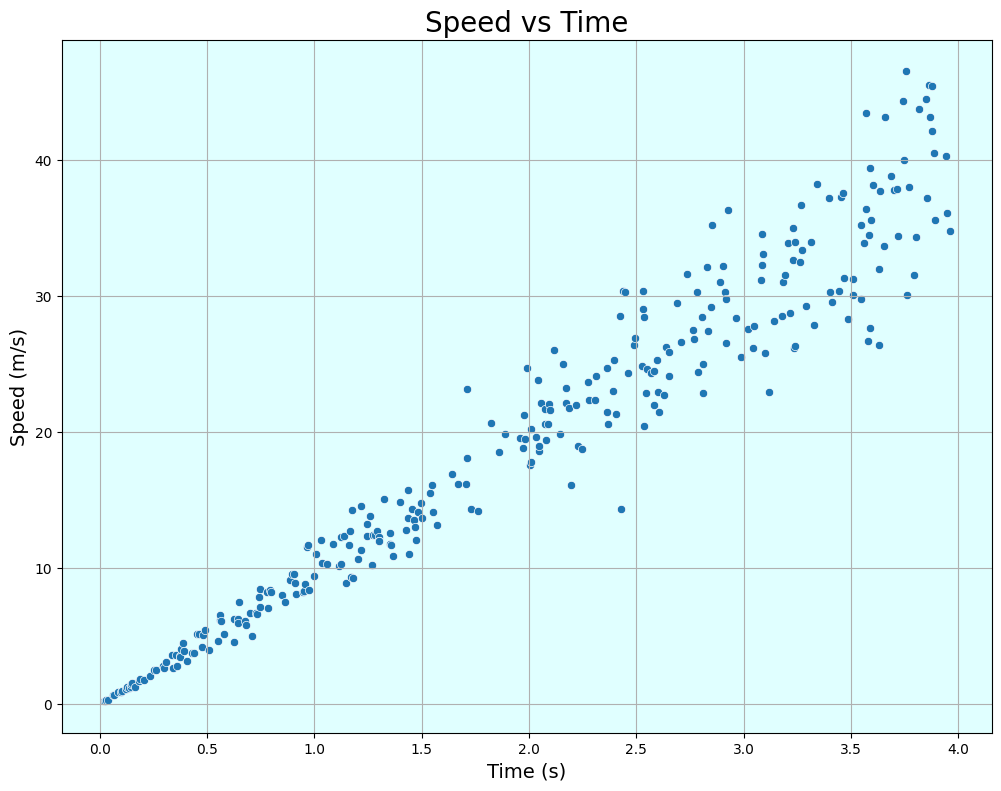

In [5]:
##=============================================================================================##
## Create a Plot of the Data:                                                                  ##
##=============================================================================================##

# Set the title of the plot:

title = "Speed vs Time"

# Set the x-axis and y-axis labels:

x_label = "Time (s)"
y_label = "Speed (m/s)"

# Create a scatterplot of the feature data vs the target data:

graph_1 = plot_data([X.values, y.values], title, [x_label, y_label])

[Return to Top](#Notebook-Start)

<a name="Abstraction"></a>

---

<font size = 6> <b> 7. Abstraction: Develop A Model </b> </font>

---

<font size = 5> <b> 7.1 Building A Model </b> </font>

After we explore the data and have a general sense of how the [system](#Definition-System) behaves, the next step is to <b>abstract</b> that behavior into a mathematical [model](#Definition-Model). This process involves simplifying the system while keeping the most important parts. There are three key decisions to make during abstraction:

<br>

1. <b>Choose a Target</b>:

    First, we decide what aspect of the system we want to [predict](#Definition-Prediction) or estimate. This is our [target](#Definition-Target) variable. It's the outcome we are trying to model. The target should be something measurable that reflects how the system behaves.

    ><b>Example</b>: Are we predicting a car's fuel efficiency? The failure torque of a steel bolt? The number of infections during an outbreak?

  <br>

2. <b>Choose Key Features</b>:

    Next, we identify the parts of the system that meaningfully influence the target. These are our [feature](#Definition-Feature) variables. They are the inputs to our model. Choosing features is one of the most important (and sometimes tricky) parts of modeling. Should we include air resistance? Wind speed? Temperature? We are often tempted to include more features than we need. It might feel counterintuitive to leave out certain details, but <b>simplification is the essence of modeling</b>. A model is always a simplified version of the real system. This is what makes a model manageable and useful.

    ><b>Example</b>: Think of a map. If it had the same detail and scale as the real world, it wouldn't be useful. A good map simplifies things enough to help us navigate, and a good model works the same way.

  <br>

3. <b>Define the Relationships</b>:

    Finally, we describe how our features relate to the target. This is the structure of the model, and it’s usually expressed using equations or functions. The goal is to capture the essential behavior of the system with something manageable; something we can compute, interpret, and improve.

<br>

In short, a model is a set of rules (or equations) that describe how a few key features (measurable properties of the system) interact to produce a target (observable system behavior).

<center>$\rule$</center>

<font size = 5> <b> 7.2 Free-Fall Model </b> </font>

Now, we walk through these steps using our falling object [dataset](#Definition-Dataset).

<br>

1. <b>Choose the Target</b>:
  
    We want to model how the speed of a falling object changes over time. So, our [target](#Definition-Target) variable is <b>Speed (m/s)</b> (the object's speed at a given moment).

  <br>


2. <b>Choose the Feature(s)</b>:

    Again, we want to model how the speed of a falling object changes over time.
    So our [feature](#Definition-Feature) variable is <b>Time (s)</b> (the object's current fall time).

  <br>

3. <b>Define the Relationship</b>:

    In our [scatterplot](#Definition-Scatterplot), the relationship between an object's fall time and its current speed seems roughly linear. So, we use a simple [linear model](#Definition-Linear-Model), which has the form:

  <br>

  <center>
  <font size = 5>
  $v\of{t} = c \cdot t + b$
  </font>
  </center>

  <br>

  * $\large v\of{t}$ is the speed at time $t$.

  <br>

  * $\large c$ is the [linear coefficient](#Definition-Linear-Coefficient) (or slope), which tells us how quickly the object's speed increases over time.

  <br>

  * $\large b$ is the [bias](#Definition-Bias) (or intercept), which represents the object's speed at time $t=0$ seconds.

  <br>

><b>Note</b>: We don't know ahead of time that the relationship between the feature and the target is strictly linear. But a linear model is often a useful first approximation. In later lessons we explore non-linear models to understand more complex relationships.

[Return to Top](#Notebook-Start)

<a name="Implementation"></a>

---

<font size = 6> <b> 8. Implementation: Trying Specific Models </b> </font>

---

<font size = 5> <b> 8.1 Implementing A Model </b> </font>

A [model](#Definition-Model) becomes useful when we can actually apply it to make [predictions](#Definition-Prediction) or to better understand how a [system](#Definition-System) behaves. This stage is called <b>implementation</b>. To implement a model, we plug in specific values for our [features](#Definition-Feature) and calculate the corresponding predictions of the [target](#Definition-Target) variable. In our case, that means using values of time to predict the speed of the falling object.

<center>$\rule$</center>

<font size = 5> <b> 8.2 Estimating Our Coefficients </b> </font>

Looking at the [scatterplot](#Definition-Scatterplot), we notice that the speed values (our [target](#Definition-Target)) increase approximately 10 times faster than time values (our [feature](#Definition-Feature)). That suggests that the [linear coefficient](#Definition-Linear-Coefficient) ($\large c$) in our [model](#Definition-Model) might be somewhere around 10 $\large \mpss$. To test our intuition, let's try a few models, each with a different linear coefficient:

  <br>

  * <b>Model 1</b>: ($\large c = 9 \spc \mpss$)

  <br>

  * <b>Model 2</b>: ($\large c = 10 \spc \mpss$)

  <br>

  * <b>Model 3</b>: ($\large c = 11 \spc \mpss$)

<br>

To simplify things, we assume that the falling object starts from rest. That means the speed ($\large v =  0 \spc \mps$) at time ($t = 0 \spc \textrm{s}$). We reflect this in our model by setting the [bias](#Definition-Bias) term to zero ($\large b = 0 \spc \mps$), giving us the simplified equation:

<br>

  <center>
  <font size = 5>
  $v\of{t} = c \cdot t$
  </font>
  </center>

<center>$\rule$</center>

<font size = 5> <b> 8.3 Visual Comparison of the Models </b> </font>

Next, we plot all three [models](#Definition-Model) on the same graph alongside the original data points. This visual comparison helps us quickly see how the models compare to the observed trend.

<br>

><b>Note</b>: At this stage, we aree not trying to find a perfect fit. We are just building intuition. Our goal is to understand how changing the [linear coefficient](#Definition-Linear-Coefficient) affects the model's behavior.

<br>

When we look at the plots, we notice that:

  <br>

  * If the linear coefficient is too large, the model overshoots the data.

  <br>

  * If the linear coefficient is too small, the model undershoots the data.

  <br>

  * If the linear coefficient is close to the best-fit value, the model closely aligns with the data.

<br>

This kind of trial-and-error approach, guided by visual feedback, is a powerful way to start refining our model before jumping into more formal optimization methods.

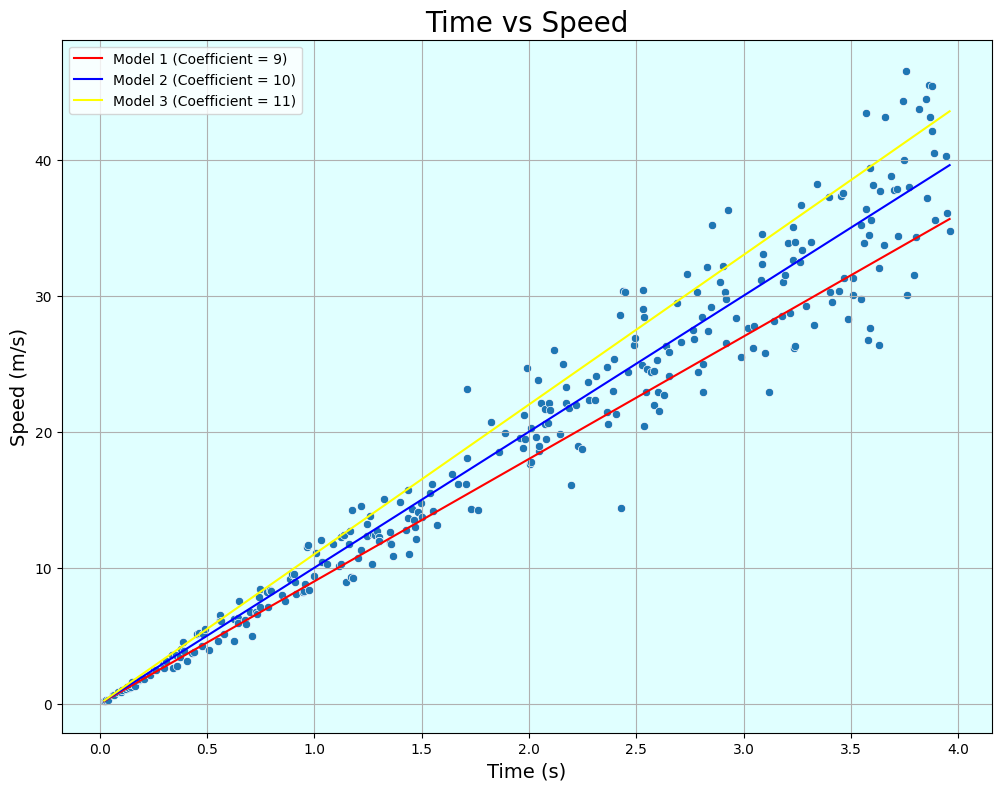

In [6]:
##=============================================================================================##
## Create Model 1 (Coefficient = 9, Bias = 0):                                                 ##
##=============================================================================================##

# Set the coefficient of model 1:

coef_1 = 9.0

# Set the bias of model 1:

bias_1 = 0

# Create model 1:

model_1 = X * coef_1 + bias_1

# Set the graph label for model 1:

label_1 = "Model 1 (Coefficient = 9)"

# Set the model 1 color:

color_1 = 'red'

##=============================================================================================##
## Create Model 2 (Coefficient = 10, Bias = 0):                                                ##
##=============================================================================================##

# Set the coefficient of model 2:

coef_2 = 10.0

# Set the bias of model 2:

bias_2 = 0

# Create model 2:

model_2 = X * coef_2 + bias_2

# Set the graph label for model 2:

label_2 = "Model 2 (Coefficient = 10)"

# Set the model 2 color:

color_2 = 'blue'

##=============================================================================================##
## Create Model 3 (Coefficient = 11, Bias = 0):                                                ##
##=============================================================================================##

# Set the coefficient of model 3:

coef_3 = 11.0

# Set the bias of model 3:

bias_3 = 0

# Create model 3:

model_3 = X * coef_3 + bias_3

# Set the graph label for model 3:

label_3 = "Model 3 (Coefficient = 11)"

# Set the model 3 color:

color_3 = 'yellow'

##=============================================================================================##
## Create a Plot of the Data:                                                                  ##
##=============================================================================================##

# Set the title of the plot:

title = "Time vs Speed"

# Set the x-axis and y-axis labels:

x_label = "Time (s)"
y_label = "Speed (m/s)"

# Set the feature data vs the target data for the scatterplot:

data = [X.values, y.values]

# Create the model list:

model_list = [model_1, model_2, model_3]

# Set the color list:

color_list = [color_1, color_2, color_3]

# Set the label list:

label_list = [label_1, label_2, label_3]

# Create a scatterplot of the feature data vs the target data:

graph_2 = plot_data(data, title, [x_label, y_label], model_list, color_list, label_list)

[Return to Top](#Notebook-Start)

<a name="Validation"></a>

---

<font size = 6> <b> 9. Validation: Introducing Error and Loss Functions </b> </font>

---

<font size = 5> <b> 9.1 Validating the Model </b> </font>


A [model](#Definition-Model) is only useful if it does a good job reflecting the real-world system it's meant to represent. That's where <b>validation</b> comes in. Validation is testing how well a model performs by comparing its [predictions](#Definition-Prediction) to actual data. Let's go back to the three models we plotted earlier:

  <br>

  * <b>Model 1</b> $\large (c = 9 \spc \mpss)$:
  
    This model consistently underestimates the object's speed. The line falls below most of the data points. This tells us that the linear coefficient is likely too small.

  <br>

  * <b>Model 3</b> $\large (c = 11 \spc \mpss)$:
   
    This model consistently overestimates the object's speed. The line stays above most of the data points. This tells us that the linear coefficient is likely too large.

  <br>

  * <b>Model 2</b> $\large (c = 10 \spc \mpss)$:
  
    This model appears to follow the data more closely than the other two models and seems like a reasonable fit. This tells us that the linear coefficient is likely near to the best-fit value.

<center>$\rule$</center>

<font size = 5> <b> 9.2 How Do We Measure Accuracy? </b> </font>

The kind of visual inspection we just did is a helpful first step, but it's not rigorous enough on its own. In science and engineering, we often need a quantitative way to evaluate how well a [model](#Definition-Model) performs, something more comprehensive than just eyeballing a graph. That's where [error](#Definition-Error) and [loss functions](#Definition-Loss-Function) come in.

<br>

Our model is a simple [linear function](#Definition-Linear-Model) without a [bias](#Definition-Bias) term, so it's [target](#Definition-Target) value [prediction](#Definition-Prediction) ($\large \hat{y}_i$) for each input [feature](#Definition-Feature) value ($\large X_i$) takes the form:

<br>

<center>
<font size = 5>
$\hat{y}_i = c \cdot X_i$
</font>
</center>

<br>

Since a model's error ($\large e_i$) is the difference between the actual target value ($\large y_i$) and the model's predicted target value ($\large \hat{y}_i$) for a given feature value ($\large X_i$), we can write it mathematically as:

<br>

<center>
<font size = 5>
$
\begin{array}{l l}
e_i & = y_i - \hat{y}_i \\&\\
& = y_i - c \cdot X_i
\end{array}
$
</font>
</center>

<br>

Loss functions take in all of a model's errors and combine them into a single quantity that allows us to quantify the quality of the model's fit to the data. Loss functions are extremely useful because they allow us to move from subjective judgments to objective evaluation. Rather than saying, "this line looks like a better fit", we can point to a concrete metric: the model with the lower loss score is the better-performing model.

<center>$\rule$</center>

<font size = 5> <b> 9.3 Root Mean Squared Error Loss Function </b> </font>

In this lesson, we use a common loss function called [Root Mean Squared Error](#Definition-RMSE) (RMSE). RMSE tells us, on average, how big the [model's](#Definition-Model) [prediction](#Definition-Prediction) [errors](#Definition-Error) are.

<br>

<center>
<font size = 5>
$
\begin{array}{l l}
\textrm{RMSE} & = \sqrt{\displaystyle \frac{1}{N} \displaystyle\sum\limits_{i=1}^{N} \hspace{0.2 pc} (e_i)^2}\\&\\
& = \sqrt{\displaystyle \frac{1}{N} \displaystyle\sum\limits_{i=1}^{N} \hspace{0.2 pc} (y_i - c \cdot X_i)^2}
\end{array}
$
</font>
</center>

  <br>

  * $\large N$ is the number of data points.

  <br>

  * $\large e_i$ is the error for the ith data point.

  <br>

  * $\large y_i$ is the actual value of the [target](#Definition-Target) for the ith data point.

  <br>

  * $X_i$ is the the value of the [feature](#Definition-Feature) for the ith data point.

<center>$\rule$</center>

<font size = 5> <b> 9.4 Why Use RMSE As Our Loss Function? </b> </font>

We use [RMSE](#Definition-RMSE) for a few important reasons:

  <br>

  * By squaring the [error](#Definition-Error), RMSE penalizes large errors more strongly.

  <br>

  * The [loss](#Definition-Loss-Function) value it produces in the same units as the [target](#Definition-Target) variable (in our case, meters per second), which makes it easy to interpret.

  <br>

  * RMSE is widely used and understood, making it a good standard for comparing [models](#Definition-Model).

<br>

><b>Note</b>: RMSE is sensitive to outliers. A single extreme data point can significantly increase the loss score. That's why it's often a good idea to identify and remove significant outliers before evaluating your model's loss.

In [9]:
##=============================================================================================##
## Function:  root_mean_squared_error                                                          ##
##                                                                                             ##
## Purpose:   Implement the Root Mean Squared Error Loss Function                              ##
##                                                                                             ##
## Input(s):  X           - feature (independent) data                                         ##
##            y           - target (dependent) data                                            ##
##            coefficient - slope of the linear model                                          ##
##            bias        - bias of the linear model                                           ##
##                                                                                             ##
## Output(s): rmse        - root mean squared error                                            ##
##=============================================================================================##

def root_mean_squared_error(X, y, coefficient, bias):

  # Create the model's predictions based on a linear combination of the feature data

  predictions = X * coefficient + bias

  # Calculate the squared error:

  squared_error = (y - predictions)**2

  # Find the mean of the squared error:

  mse = squared_error.mean()

  # Take the square root of the mean squared error:

  rmse = np.sqrt(mse)

  # Return the root mean squared error:

  return rmse

<center>$\rule$</center>

<font size = 5> <b> 9.5 Using RMSE to Evaluate Model Accuracy </b> </font>

Now that we introduced [Root Mean Squared Error](#Definition-RMSE) (RMSE) as our evaluation metric, we can use it to quantitatively assess how well each of our three [models](#Definition-Model) performs. By calculating RMSE, we move from a qualitative visual judgement to a quantitative, evidence-based comparison. This approach is especially helpful when differences between models aren't obvious by eye, or when we have more data dimensions than we can comfortably plot.

<br>

><b>Note</b>: In later lessons, we explore models that use multiple [features](#Definition-Feature) (multivariate linear regression). In those cases, visualizing the model's fit isn't even possible in 2D. That's when metrics like RMSE become essential tools for evaluating, comparing, and improving models.

In [10]:
##=============================================================================================##
## Compute the Root Mean Squared Error for the Models:                                         ##
##=============================================================================================##

# Compute RMSE for model 1:

model_1_rmse = root_mean_squared_error(X, y, coef_1, bias_1)

# Compute RMSE for model 2:

model_2_rmse = root_mean_squared_error(X, y, coef_2, bias_2)

# Compute RMSE for model 3:

model_3_rmse = root_mean_squared_error(X, y, coef_3, bias_3)

##=============================================================================================##
## Display The Results:                                                                        ##
##=============================================================================================##

# Create a DataFrame to hold the results:

results_df = pd.DataFrame()

# Set the title for the results:

results_title = "Root Mean Squared Error (meters per second)"

# Add the model names:

results_df["Model"] = ["Model 1", "Model 2", "Model 3"]

# Add the RMSE values:

results_df["RMSE"] = [np.round(model_1_rmse, 2), np.round(model_2_rmse, 2),
                      np.round(model_3_rmse, 2)]

# Display the results:

results_df.set_index("Model", inplace = True)

display_dataframes([results_df], [results_title])

,RMSE
Model,
Model 1,3.47
Model 2,2.85
Model 3,3.86


<center>$\rule$</center>

<font size = 5> <b> 9.6 Loss Function Results </b> </font>

Here are the [RMSE](#Definition-RMSE) [loss](#Definition-Loss-Function) values for our three [models](#Definition-Model):

  <br>

  * <b>Model 1</b> ($\large c = 9 \spc \mpss$): RMSE = 1.80 meters per second

  <br>

  * <b>Model 2</b> ($\large c = 10 \mpss$): RMSE = 1.51 meters per second

  <br>

  * <b>Model 3</b> ($\large c = 11 \mpss$): RMSE = 1.99 meters per second

<br>

These results confirm what we saw earlier: Model 2 ($\large c = 10 \mpss$)
had the best-fit to the data of the three models. The RMSE loss function gives us a numerical confirmation of our visual intuition and provides a more reliable way to evaluate model performance going forward.

[Return to Top](#Notebook-Start)

<a name="Iteration"></a>

---

<font size = 6> <b> 10. Iteration: Improving the Model </b> </font>

---

<font size = 5> <b> 10.1 Why Do We Iterate? </b> </font>


Suppose we compare our [model's](#Definition-Model) [predictions](#Definition-Prediction) to real-world data and find they're off by about 10%. Is that "good enough"? Or should we try to improve the model? The answer depends on what we're using the model for. In many scientific and engineering contexts, small [errors](#Definition-Error) might be acceptable. In others, even a small discrepancy might be critical. Regardless, model building is almost always an <b>iterative</b> process:

<br>

  1. We start with a simple model and initial values for the model's parameters.

  <br>

  2. We evaluate the model using a [loss function](#Definition) to determine if the model performs well enough to meet our needs.

  <br>

  3. If we determine that the model's performance is insufficient, we improve the model, or try different parameters.

  <br>
  
  4. We repeat the process until we get a model that meets our needs.

<br>

Our goal isn't to create the most complicated and realistic model possible. More complexity doesn't always mean a better model. In fact, simpler models are often preferred as they're easier to understand, faster to compute, and often provide more insight into how the system works. <b>Our goal, thus, is to find the right balance between accuracy and simplicity</b>.

<center>$\rule$</center>

<font size = 5> <b> 10.2 Expanding the Search for the Best-Fit Model </b> </font>

We can continue to improve our [model](#Definition-Model) by testing more [linear coefficient](#Definition-Linear-Coefficient) values to find the one that minimizes the [RMSE](#Definition-RMSE) [loss function](#Definition-Loss-Function). This process is called a [parameter search](#Definition-Parameter-Search). Previously, we tested three models and, from the RMSE scores, we saw that Model 2 ($\large c = 10 \mpss$) performed the best. Thus, we focus our search near that value. Our parameter search consists of trying 100 different models with linear coefficients evenly spaced between ($\large c = 9 \mpss$) and ($\large c = 11 \mpss$). We evaluate each model by calculating its RMSE score. We then make a plot of linear coefficients vs. RMSE. This plot will help us visually identify the linear coefficient that produces the lowest loss, giving us the best-fit linear model.

<br>

><b>Note</b>: This process of adjusting model parameters to reduce [error](#Definition-Error) is foundational to modern data modeling and machine learning. It's how we train models to best reflect the data they're given.

,
,
Minimum RMSE,2.84
Best Coefficient,9.87


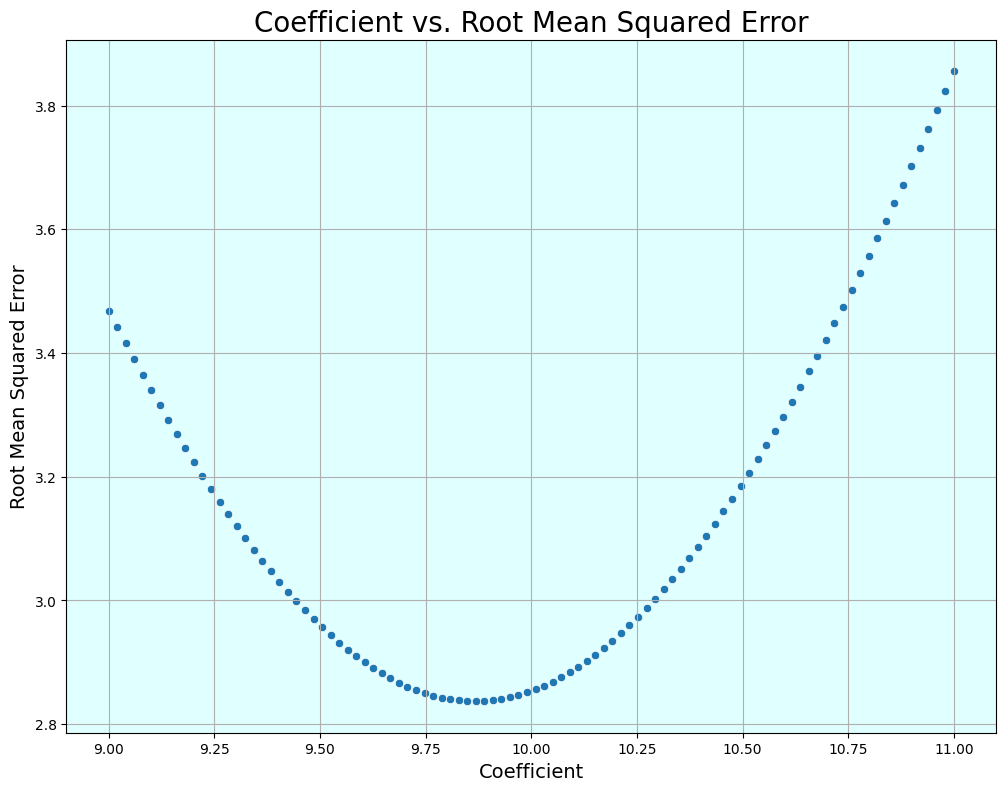

In [23]:
##=============================================================================================##
## Compute the Root Mean Squared Error Loss Function for A Large Number of Models:             ##
##=============================================================================================##

# Create a list of coefficients:

coef_list = np.linspace(9.0, 11.0, 100)

# Calculate the Root Mean Squared Error for the list of coefficients, and store the values in a
# Pandas Series (DataFrame column):

rmses = pd.Series([root_mean_squared_error(X, y, coef, 0) for coef in coef_list])

##=============================================================================================##
## Compute the Root Mean Squared Error For Each Coefficient:                                   ##
##=============================================================================================##

plot_data([coef_list, rmses], "Coefficient vs. Root Mean Squared Error",
          ["Coefficient", "Root Mean Squared Error"])

##=============================================================================================##
## Find the Coefficient With the Minimum Root Mean Squared Error:                              ##
##=============================================================================================##

# Use numpy min function to get the smallest value in the RMSE Series:

min_rmse = np.min(rmses)

# Get the model coefficient that is associated with the smallest RMSE score:

best_fit = coef_list[np.where(rmses == min_rmse)]

##=============================================================================================##
## Display The Results:                                                                        ##
##=============================================================================================##

# Create a DataFrame to hold the results:

results_df = pd.DataFrame()

# Set the title for the results:

results_title = "Best-Fit Model"

# Add the row names (column name is " "):

results_df[" "] = ["Minimum RMSE", "Best Coefficient"]

# Add the row values (column name is ""):

results_df[""] = [np.round(min_rmse, 2), np.round(best_fit[0], 2)]

# Set the " " column as the index:

results_df.set_index(" ", inplace = True)

# Display the results:

display_dataframes([results_df], [results_title])

<center>$\rule$</center>

<font size = 5> <b> 10.3 What is the Best-Fit Model? </b> </font>

From our plot of <b>Coefficient vs. RMSE</b>, we see that the minimum [RMSE](#Definition-RMSE) [loss](#Definition-Loss-Function) occurs at approximately ($\large c = 9.87 \mpss$). By minimizing the RMSE loss, we've found, quantitatively, that a [model](#Definition) with a [linear coefficient](#Definition-Linear-Coefficient) of around 9.87 meters per second squared provides the best fit to the data among all the models we tested. This result highlights two essential lessons in model building:

  <br>

  * Even simple models can reveal meaningful patterns and reflect real-world physical laws.

  <br>

  * We can (and should) rely on quantitative evaluation, not just visual intuition, to guide how we improve our models.

<br>

By iterating and testing, we move closer to a model that captures both the behavior and structure of the system we're studying.

[Return to Top](#Notebook-Start)

<a name="Interpretation"></a>

---

<font size = 6> <b> 11. Interpretation: Gaining Physical Understanding </b> </font>

---

<font size = 5> <b> 11.1 Why Does Interpretation Matter? </b> </font>

So far in this lesson, we built a [model](#Definition-Model), tested its accuracy, refined it to minimize [error](#Definition-Error), and found a strong fit to the data. But modeling isn't just about generating [predictions](#Definition-Prediction) or minimizing [loss](#Definition-Loss-Function). It's also about developing insight into the [system](#Definition-System) itself. So what does our final model actually tell us about the physics of falling objects?

<center>$\rule$</center>

<font size = 5> <b> 11.2 What Does The Linear Coefficient Tell Us?</b> </font>

Our best-fit [model](#Definition-Model) has the form:

<br>

<center>
<font size = 5>
 $v\of{t} = 9.87 \cdot t$
</font>
</center>

<br>

This equation tells us that, according to the data, an object's speed increases by approximately 9.87 meters per second for every second it falls. In other words, our model estimates the acceleration due to local gravity as:

<br>

<center>
<font size = 5>
 $g_{(\textrm{model})} \approx 9.87 \pm \spc 2.84 \mpss$
</font>
</center>

<br>

Realistically, we should truncate our values here to two significant digits.

<br>

<center>
<font size = 5>
 $g_{(\textrm{model})} \approx 9.9 \pm \spc 2.8 \mpss$
</font>
</center>

<br>

Our result closely aligns with the accepted value of gravitational acceleration near Earth's surface:

<br>

<center>
<font size = 5>
 $g_{(\textrm{actual})} \approx 9.81 \mpss$
</font>
</center>

<br>

Because the actual value falls comfortably within our model's error margin (as estimated by [RMSE](#Definition-RMSE)), we can conclude that our model not only fits the data well, <b>it also captures a real physical law</b>.

><b>Note:</b> The error here is quite large on purpose. The simulated data was meant to represent the sort of noisy data that can often arise in the real world. A subsequent experiment would need a refined procedure to try and reduce this error in order to find a better value.

<center>$\rule$</center>

<font size = 5> <b> 11.3 Why This Is Powerful </b> </font>

This is where the process of modeling shows its true power. With just a [dataset](#Definition-Dataset) of time and speed measurements, and a simple [linear model](#Definition-Linear-Model), we uncovered a fundamental constant of nature. Furthermore, we did it without directly measuring acceleration or using formal physics equations. We did this by analyzing patterns in the data, builing a predictive [model](#Definition-Model), minimizing prediction [error](#Definition-Error) with a [parameter search](#Definition-Parameter-Search), and interpreting the model parameters in a physical context.

<center>$\rule$</center>

<font size = 5> <b> 11.4 Visualizing The Best-Fit Model </b> </font>

To reinforce our understanding, we now add our best-fit [model](#Definition-Model) on the same plot as the original data, along with:

  <br>

  * A shaded band representing the $\pm$ [RMSE](#Definition-RMSE) range

  <br>

  * A comparison line representing the accepted gravitational acceleration: $g_{(\textrm{actual})} = 9.81 \mpss$

<br>

This final visualization shows not just a good fit to the data, but reinforces how well our model matches real-world physics.

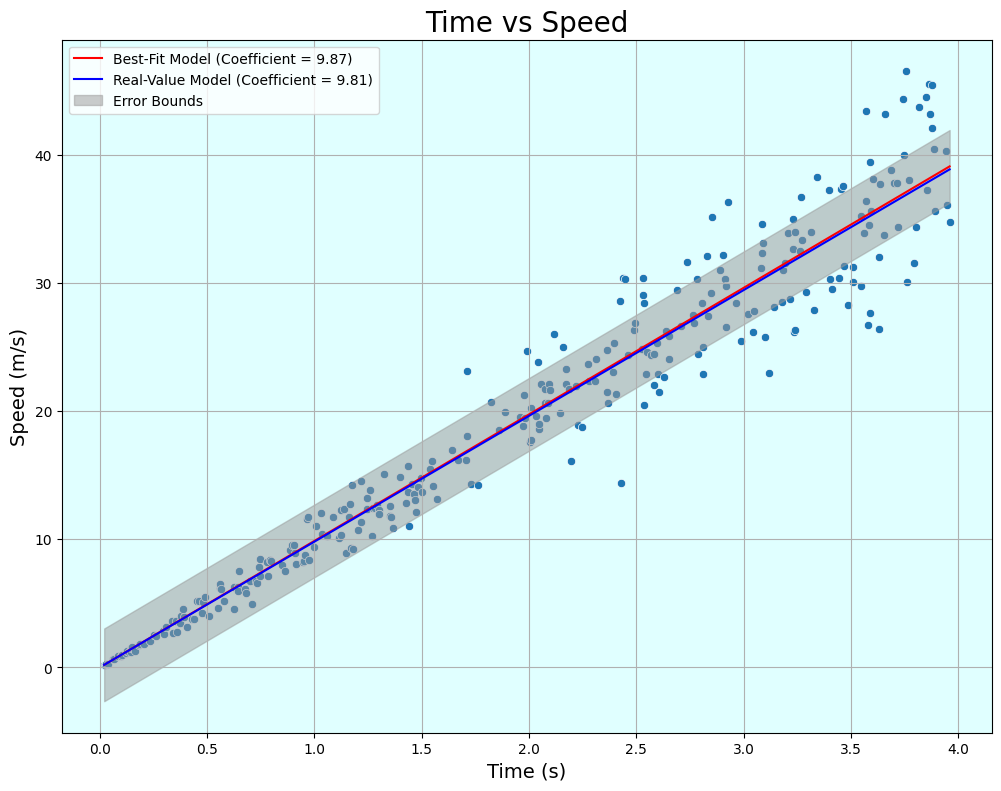

In [24]:
##=============================================================================================##
## Create The Best-Fit Model (g = 9.87 m/s^2):                                                 ##
##=============================================================================================##

# Set the coefficient of the best-fit model:

coef_best = best_fit[0]

# Set the bias of the best-fit model:

bias_best = 0

# Create the best-fit model:

model_best = X * coef_best + bias_best

# Set the graph label for the best-fit model:

model_best_label = "Best-Fit Model (Coefficient = 9.87)"

# Set the best-fit model color:

model_best_color = 'red'

# Set the best-fit model RMSE:

model_best_rmse = min_rmse

##=============================================================================================##
## Create The 'Real-Value' Model (g = 9.81 m/s^2):                                             ##
##=============================================================================================##

# Set the coefficient of the best-fit model:

coef_real = 9.81

# Set the bias of the best-fit model:

bias_real = 0

# Create the best-fit model:

model_real = X * coef_real + bias_real

# Set the graph label for the best-fit model:

model_real_label = "Real-Value Model (Coefficient = 9.81)"

# Set the best-fit model color:

model_real_color = 'blue'

##=============================================================================================##
## Create a Plot of the Data:                                                                  ##
##=============================================================================================##

# Set the title of the plot:

title = "Time vs Speed"

# Set the x-axis and y-axis labels:

x_label = "Time (s)"
y_label = "Speed (m/s)"

# Set the feature data vs the target data for the scatterplot:

data = [X.values, y.values]

# Create the model list:

model_list = [model_best, model_real]

# Set the color list:

color_list = [model_best_color, model_real_color]

# Set the label list:

label_list = [model_best_label, model_real_label]

# Create a plot of the best-fit model along with the error bounds:

graph_3 = plot_data(data, title, [x_label, y_label], model_list, color_list, label_list,
                    error_display = True, error = model_best_rmse)

The shaded band shows the region around the average value $\pm$ the RMSE. If the errors are truly random, the data will be spread around the true value ($\mu$) according to a gaussian distribution and the RMSE represents $\sigma$ in the distribution.

<br>

<center>
<div>
<img src="https://raw.githubusercontent.com/dr-bankert-augustana/PHYS_200/refs/heads/main/Images/Module_2/gaussian-sd.png" width="700"/>
</div>
</center>

<center>$\rule$</center>

<font size = 5> <b> 11.5 Understanding Model Limitations </b> </font>

Even the best [models](#Definition-Model) have limitations that arise from their simplifying assumptions. It's critical for us to understand those limits so we don't stumble into incorrect conclusions. In creating our model, we made the following assumptions:

  <br>

  * <b>No air resistance</b>: We assumed the object is falling in a vacuum environment. In real conditions, drag forces become significant, especially at higher speeds.

  <br>

  * <b>Linear motion only</b>: This model assumes constant acceleration due to local gravity. This assumption works well enough near Earth's surface, but breaks down at very high altitudes where local gravity varies with height.

  <br>

  * <b>Zero initial speed</b>: We assumed that the object starts from rest. Real-world scenarios may involve a non-zero starting velocity (which would require a nonzero [bias](#Definition-Bias) term).

<br>

A model's usefulness depends on how well its assumptions match the scenario where it's applied. Always consider where a model applies, and where it doesn't.

[Return to Top](#Notebook-Start)

<a name="Lesson-Summary"></a>

---

<font size = 6> <b> 12. Lesson Summary </b> </font>

---

In this lesson, we walked through the full process of building, testing, and interpreting a simple [linear model](#Definition-Linear-Model). We started with a [dataset](#Definition-Dataset) representing the speed of a falling object over time, and used it to build a [model](#Definition-Model) of the system. We chose a [target](#Definition-Target) variable (speed), identified a relevant[feature](#Definition-Feature) (time), and proposed a relationship between them (a linear model). We implemented the model using specific values of the feature data to make [predictions](#Definition-Prediction) of the target variable. To evaluate how well our model worked, we introduced the concept of [error](#Definition-Error) and [loss functions](#Definition-Loss-Function), specifically [Root Mean Squared Error](#Definition-RMSE) (RMSE). This gave us a way to measure model accuracy objectively and compare different models based on how closely their predictions matched the data. Finally, we refined our model through iteration and further testing.

<br>

Through this process, we found that our best-fit model predicted that a falling object's speed increases by approximately 9.87 meters per second for each second of falling. This value aligned closely with the known value of 9.81 $\mpss$, demonstrating that even a simple model, built carefully from data, can reveal deep truths about the physical world. Importantly, we also discussed the limits of our model and emphasized a core concept of model building: A model is only as good as the assumptions behind it and its fit to the situation it's meant to describe.

<br>

In later lessons, we encounter more complex models that use multiple features, nonlinear relationships, and automated techniques for improving accuracy. However, the core ideas we learned and practiced here on simple models will still form the foundation of our approach.

[Return to Top](#Notebook-Start)

<a name="Appendix-Definitions"></a>

---

<font size = 6> <b> Appendix A: New Term Definitions </b> </font>

---

<a name="Definition-Bias"></a>
* <font size = 4> <b> Bias: </b> </font>

    The bias (also called the intercept) is the value of the target variable when all feature values are zero. In a 2D plot, it tells us where the model's line crosses the vertical axis.

<br>

<a name="Definition-Dataset"></a>
* <font size = 4> <b> Dataset: </b> </font>

    A dataset is a collection of related data, usually organized in a table, where each row represents a single observation or measurement, and each column represents a different variable or property.

<br>

<a name="Definition-Error"></a>
* <font size = 4> <b> Error: </b> </font>

    In modeling, error is the difference between the model’s prediction and the actual observed value for a given set of feature values. It tells us how far off the model’s guess was.

    <center>
    <font size = 5>
    Error = Actual Value $-$ Predicted Value
    </font>
    </center>

<br>

<a name="Definition-Feature"></a>
* <font size = 4> <b> Feature: </b> </font>

    A feature is a measurable property of a system that we use to help predict or understand the target.

<br>

<a name="Definition-Linear-Coefficient"></a>
* <font size = 4> <b> Linear Coefficient: </b> </font>

    A linear coefficient (also called the 'slope') is the value that tells us how much the target variable changes when the associated feature variable increases by one unit amount in a linear model.

<br>

<a name="Definition-Linear-Model"></a>
* <font size = 4> <b> Linear Model: </b> </font>

    A linear model describes a straight-line relationship between one or more features ($\large X$) and a target ($\large y$). The linear coefficient(s) ($\large c$) describe how much the target changes for each unit change of the feature(s). The bias ($\large b$) is the value of the target when the feature(s) are zero.

  <center>
  <font size = 5>
  $y = c \cdot X + b$
  </font>
  </center>

  <br>

<a name="Definition-Loss-Function"></a>
* <font size = 4> <b> Loss Function: </b> </font>

    A loss function is a mathematical formula that takes in all of a model's errors and combines them into a single number, called the loss, which tells us how well (or poorly) the model is performing. The lower the loss, the better the model's predictions match the actual data. This gives us a direct, measurable way to compare multiple models on the same data.
    
<br>

<a name="Definition-Model"></a>
* <font size = 4> <b> Model: </b> </font>

    A model is a simplified representation of a system that describes some manner about how the system behaves.

<br>

<a name="Definition-Parameter-Search"></a>
* <font size = 4> <b> Parameter Search: </b> </font>

    A parameter search is the process of testing different values for a model’s parameters (like the linear coefficient or bias in a linear model) to find the combination that gives the best performance, usually by minimizing error.

<br>

<a name="Definition-Prediction"></a>
* <font size = 4> <b> Prediction: </b> </font>

    In modeling, a prediction is the model’s estimated value for a target variable based on the input feature(s) you provide.

<br>

<a name="Definition-RMSE"></a>
* <font size = 4> <b> Root Mean Squared Error: </b> </font>

    Root Mean Squared Error (RMSE) is a common loss function that measures the average size of the errors a model makes while giving more weight to larger mistakes.

<br>

<a name="Definition-Scatterplot"></a>
* <font size = 4> <b> Scatterplot: </b> </font>

    A scatterplot is a type of graph that shows individual data points using dots to represent the relationship between two variables. One variable is shown along the x-axis (horizontal). The other variable is shown along the y-axis (vertical). Each dot represents one observation or measurement containing values for both variables.

<br>

<a name="Definition-Simulation"></a>
* <font size = 4> <b> Simulation: </b> </font>

    A simulation is a method for imitating the behavior of a real-world system using a computer model. It lets us test, observe, or experiment with how a system works without needing to build or measure the real thing.

<br>

<a name="Definition-Synthetic-Dataset"></a>
* <font size = 4> <b> Synthetic Dataset: </b> </font>

    A synthetic dataset is a collection of data that is artificially generated. It is not measured or collected from the real world, but created using rules, equations, or simulations.

<br>

<a name="Definition-System"></a>
* <font size = 4> <b> System: </b> </font>

    A system is any set of processes (real or conceptual) that we want to understand or analyze. It could be the climate, an air conditioning unit, an ecosystem, or even the human body.

<br>

<a name="Definition-Target"></a>
* <font size = 4> <b> Target: </b> </font>

    A target is the system outcome we're trying to predict, explain, or understand using a model. It's usually a measurable quantity that depends on other properties of the system.

[Return to Top](#Notebook-Start)

---